# 📑 Relatório de Análise: WorldRiskIndex (WRI)
**Disciplina:** LIA (Laboratório de Inovação e Automação 1)  
**Instituição:** UFG - Engenharia de Computação
* **Data:** 15 de Março de 2026

---
> ### 👤 Abner Gabriel Monteiro Tavares
> **GitHub:** [MoAbner](https://github.com/MoAbner)  
> **Contato:** `abner_gabriel@discente.ufg.br`  
> **Disciplina:** LIA (Laboratório de Inovação e Automação 1)
---

### 🚀 Sobre o Projeto
> Este notebook apresenta uma análise exploratória e estatística dos dados globais de risco de desastres. O objetivo é aplicar técnicas de **Ciência de Dados** e **Visualização** para identificar como fatores geográficos e governamentais se correlacionam para definir o índice final de risco.

**Ferramentas Utilizadas:**
* **Linguagem:** Python 3.14
* **Bibliotecas:** Pandas (Tratamento), Plotly (Gráficos Dinâmicos)
* **Dataset:** WorldRiskIndex (Série Histórica)
* **Link para o Dataset:** [Dataset](https://www.kaggle.com/datasets/tr1gg3rtrash/global-disaster-risk-index-time-series-dataset)

---

### Estudo de Caso: Análise do Dataset Desastres Naturais
🎯 Objetivo do Estudo
Vamos aplicar todas as técnicas aprendidas para analisar um dos datasets mais famosos da ciência de dados: o desastre do Titanic!

🔍 Perguntas que vamos responder:

1. Países com a maior Exposição a desastres naturais são necessariamente os que possuem o maior Indice de Risco?
2. Quais são as 10 nações com a maior Falta de Capacidade de Resposta e como isso impacta sua posição no ranking global de risco?
3. Qual região do globo apresenta a maior média de Suscetibilidade e onde se concentram os maiores outliers?
4. Qual fator interno (Suscetibilidade, Falta_Capacidade_Resposta ou Falta_Adaptacao) possui a correlação mais forte com o Indice_Risco final?

### 📊 Sobre o Dataset (WorldRiskIndex):
- **📅 Período:** Série Histórica (2011 - 2021)
- **🌍 Abrangência:** Mais de 180 países e territórios mapeados
- **⚖️ Métricas:** Exposure, Vulnerability, Susceptibility e Coping Capacity
- **🔢 Variáveis:** Dados numéricos de risco e categorias regionais

> **🎯 Meta:** Validar se a infraestrutura e a governança (fatores humanos) conseguem mitigar o risco imposto por desastres naturais (fatores geográficos)!


## 📁 a) Carregando e Preparando os Dados
🧹 Etapas de Limpeza:
📥 Carregar o dataset
🔍 Explorar a estrutura dos dados
🧹 Limpar valores ausentes
🗂️ Preparar para análise

In [48]:
import pandas as pd

df_risk = pd.read_csv('world_risk_index.csv')

df_risk_translate_pt_br = df_risk.rename(columns={  #Traduzindo as colunas
    'Region': 'Região',
    'WRI': 'Indice de Risco',
    'Exposure': 'Exposicão',
    'Vulnerability': 'Vulnerabilidade',
    'Susceptibility': 'Suscetibilidade',
    'Lack of Coping Capabilities': 'Falta_Capacidade_Resposta',
    ' Lack of Adaptive Capacities': 'Falta de Adaptação', 
    'Exposure Category': 'Nível de Exposição',
    'WRI Category': 'Nível do Índice de Risco',
    'Vulnerability Category': 'Categoria de Vulnerabilidade',
    'Susceptibility Category': 'Categoria de Suscetibilidade'
})

print("Colunas disponíveis:", df_risk_translate_pt_br.columns)
df_risk_translate_pt_br.head()


Colunas disponíveis: Index(['Região', 'Indice de Risco', 'Exposicão', 'Vulnerabilidade',
       'Suscetibilidade', 'Falta_Capacidade_Resposta', 'Falta de Adaptação',
       'Ano', 'Nível de Exposição', 'Nível do Índice de Risco',
       'Categoria de Vulnerabilidade', 'Categoria de Suscetibilidade'],
      dtype='str')


,Região,Indice de Risco,Exposicão,Vulnerabilidade,Suscetibilidade,Falta_Capacidade_Resposta,Falta de Adaptação,Ano,Nível de Exposição,Nível do Índice de Risco,Categoria de Vulnerabilidade,Categoria de Suscetibilidade
0,Vanuatu,32.00,56.33,56.81,37.14,79.34,53.96,2011,Very High,Very High,High,High
1,Tonga,29.08,56.04,51.90,28.94,81.80,44.97,2011,Very High,Very High,Medium,Medium
2,Philippinen,24.32,45.09,53.93,34.99,82.78,44.01,2011,Very High,Very High,High,High
3,Salomonen,23.51,36.40,64.60,44.11,85.95,63.74,2011,Very High,Very High,Very High,High
4,Guatemala,20.88,38.42,54.35,35.36,77.83,49.87,2011,Very High,Very High,High,High


In [61]:
import pandas as pd

# 1. Verificação inicial de integridade
print("\n🧹 Verificando dados ausentes por coluna:")
dados_ausentes = df_risk.isnull().sum()
print(dados_ausentes[dados_ausentes > 0] if dados_ausentes.sum() > 0 else "Nenhum dado ausente!")

print("\n🔧 Realizando limpeza dos dados...")

# Lista das colunas técnicas originais
colunas_originais = [
    'Exposure', 'Vulnerability', 'Susceptibility', 
    'Lack of Coping Capabilities', ' Lack of Adaptive Capacities' # Mantido o espaço inicial
]

# 2. Limpeza: Preencher valores ausentes com a mediana
for col in colunas_originais:
    if col in df_risk.columns:
        mediana = df_risk[col].median()
        df_risk[col] = df_risk[col].fillna(mediana)

# 3. Remover linhas onde o WRI é nulo
df_risk = df_risk.dropna(subset=['WRI'])

# 4. Garantir tipagem numérica para o Plotly
df_risk[colunas_originais] = df_risk[colunas_originais].apply(pd.to_numeric, errors='coerce')

print("✅ Dataset WorldRiskIndex pronto para análise!")
print(f"📏 Dimensões finais: {df_risk.shape}")
print(f"🧹 Dados ausentes restantes: {df_risk[colunas_originais].isnull().sum().sum()}")

# Calculando métricas baseadas no WRI (World Risk Index)
wri_medio = df_risk['WRI'].mean()
total_de_analises = len(df_risk.Region)
alto_risco = len(df_risk[df_risk['WRI'] > wri_medio])

# Filtro para o último ano(2021)
ultimo_ano = df_risk['Year'].max()
df_final = df_risk[df_risk['Year'] == ultimo_ano].copy()
total_paises_2021 = len(df_final)

# Cálculo da média que será usada no gráfico
wri_mean = df_final['WRI'].mean()

ano_inicio = df_risk['Year'].min()
ano_fim = df_risk['Year'].max()

# Contando quantos países únicos existem no índice
total_paises_unicos = df_risk['Region'].nunique()

# Comparando com o total de registros
total_registros = len(df_risk)
acima_da_media = df_final[df_final['WRI'] > wri_mean]
abaixo_da_media = df_final[df_final['WRI'] <= wri_mean]

# 2. Contar as quantidades
qtd_acima = len(acima_da_media)
qtd_abaixo = len(abaixo_da_media)

# 3. Calcular a porcentagem (bom para o relatório)
pct_acima = (qtd_acima / len(df_final)) * 100

# 1. Agrupar por país e calcular a média de todas as colunas técnicas
# Isso remove a duplicidade temporal mantendo a essência do dado
df_unico = df_risk.groupby('Region').mean(numeric_only=True)
total_paises_historico = df_risk.index.nunique()
# 2. Calcular a média global (a média das médias)
wri_medio_historico = df_unico['WRI'].mean()

# 3. Separar os países únicos acima e abaixo dessa média histórica
acima_historico = df_unico[df_unico['WRI'] > wri_mean]
abaixo_historico = df_unico[df_unico['WRI'] <= wri_mean]

# 4. Resultados
print(f"\n📊 Total de registros no CSV: {total_de_analises}")
print(f"🌍 Total de países únicos processados: {len(df_unico)}")
print(f"📅 Média de registros por país: {total_registros / total_paises_unicos:.1f}")
print(f"🔴 Países historicamente ACIMA da média: {len(acima_historico)}")
print(f"🟢 Países historicamente ABAIXO da média: {len(abaixo_historico)}")
print(f"📊 Média Geral Histórica (WRI): {wri_medio_historico:.2f}")

print(f"\n📊 Análise de Performance (Ano {ultimo_ano}):")
print(f"📅 Média do Índice de Risco calculada: {wri_mean:.2f}")
print(f"🌍 Países analisados no ano de 2021: {total_paises_2021}")
print(f"🔴 Países com Risco ACIMA da média: {qtd_acima} ({pct_acima:.1f}%)")
print(f"🟢 Países com Risco ABAIXO da média: {qtd_abaixo} ({100 - pct_acima:.1f}%)")

print(f"\n🕵️‍♂️ Análise Histórica ({ano_inicio} - {ano_fim}):")
print(f"📍 Total de países únicos mapeados: {total_paises_historico}")
print(f"📊 Total de registros (linhas) no dataset: {len(df_risk)}")

print(f"\n📊 Média Global do Índice de Risco: {wri_medio:.2f}")
print(f"⚠️ Registros totais Acima da Média de Risco: {alto_risco}")
print(f"📉 Registros totais abaixo Média de Risco: {total_de_analises - alto_risco}")


🧹 Verificando dados ausentes por coluna:
WRI Category              1
Vulnerability Category    4
dtype: int64

🔧 Realizando limpeza dos dados...
✅ Dataset WorldRiskIndex pronto para análise!
📏 Dimensões finais: (1917, 12)
🧹 Dados ausentes restantes: 0

📊 Total de registros no CSV: 1917
🌍 Total de países únicos processados: 306
📅 Média de registros por país: 6.3
🔴 Países historicamente ACIMA da média: 88
🟢 Países historicamente ABAIXO da média: 218
📊 Média Geral Histórica (WRI): 7.04

📊 Análise de Performance (Ano 2021):
📅 Média do Índice de Risco calculada: 7.90
🌍 Países analisados no ano de 2021: 181
🔴 Países com Risco ACIMA da média: 68 (37.6%)
🟢 Países com Risco ABAIXO da média: 113 (62.4%)

🕵️‍♂️ Análise Histórica (2011 - 2021):
📍 Total de países únicos mapeados: 1917
📊 Total de registros (linhas) no dataset: 1917

📊 Média Global do Índice de Risco: 7.55
⚠️ Registros totais Acima da Média de Risco: 726
📉 Registros totais abaixo Média de Risco: 1191


### 📉 Gráfico de Dispersão: Dinâmica do Risco Global

Este gráfico de bolhas (*Bubble Chart*) é a peça central da nossa análise. Ele cruza dados de ameaças naturais com a capacidade de resposta das nações.

- **📅 Contexto:** Dados baseados no ano mais recente da série histórica.
- **📍 Eixo X (Exposição):** Representa o perigo geográfico (probabilidade de eventos naturais).
- **📍 Eixo Y (WRI):** O Índice de Risco Final.
- **🚨 Linha Vermelha:** Média Global de Risco. Países acima dessa linha exigem atenção prioritária.
- **⭕ Diâmetro das Bolhas:** Proporcional à **Vulnerabilidade**. Bolhas maiores indicam infraestruturas mais frágeis.

> **🎯 Meta:** Visualizar a eficácia da gestão de crise. Países com bolhas pequenas e baixos no eixo Y são modelos de resiliência, mesmo quando a exposição natural é alta!

---

#### 💡 Guia de Leitura Rápida:
* **Abaixo da Linha:** Países que conseguem mitigar os perigos naturais através de infraestrutura e governança.
* **Acima da Linha:** Nações em estado crítico, onde a falta de preparação potencializa o impacto dos eventos naturais.
* **Interatividade:** O gráfico é dinâmico. Utilize o *hover* (passar o mouse) para identificar o país específico e suas métricas detalhadas.

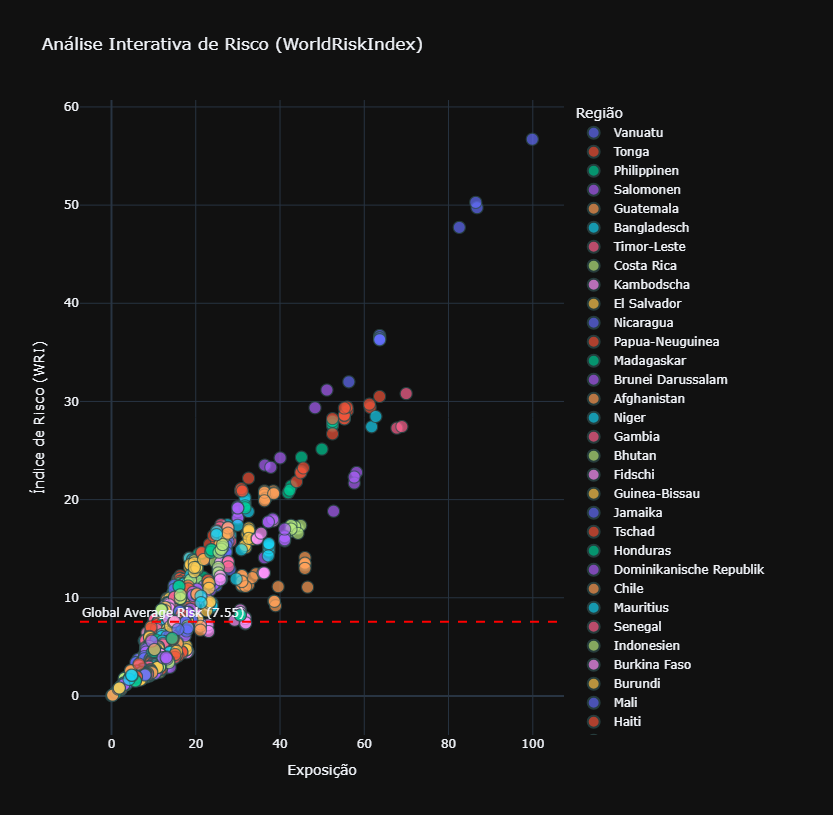

In [8]:
import plotly.express as px

# Isso transforma o nome do país (se estiver no índice) em uma coluna real chamada 'index'
df_plot = df_risk.reset_index()
# 1. Calcular a média do WRI
wri_mean = df_risk['WRI'].mean()

fig = px.scatter(
    df_plot, 
    x="Exposure", 
    y="WRI", 
    color="Region",       
    size="Vulnerability", 
    hover_name="index",    # Usamos 'index' que agora contém o identificador/país
    title="Análise Interativa de Risco (WorldRiskIndex)",
    # tamanho do gráfico
    width=1200,  
    height=800,   
    labels = {
        "Exposure": "Exposição ao Risco",
        "WRI": "Índice de Risco Global",
        "Region": "Região do Planeta",
        "Vulnerability": "Vulnerabilidade Social",
        "index": "País"
    },
    template="plotly_dark"
)

fig.add_hline(
    y=wri_mean, 
    line_dash="dash", 
    line_color="red", 
    annotation_text=f"Global Average Risk ({wri_mean:.2f})", 
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Exposição",
    yaxis_title="Índice de Risco (WRI)",
    legend_title_text="Região",
    
)

fig.update_traces(marker=dict(size=12, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

## 📊 b) Análise Exploratória com Gráficos

Vamos usar visualizações para responder nossas perguntas de pesquisa!


### Pergunta 1. Países com a maior Exposição a desastres naturais são necessariamente os que possuem o maior Indice de Risco?

> **Objetivo:** Identificar se a infraestrutura (vulnerabilidade) consegue mitigar o risco de um evento natural.


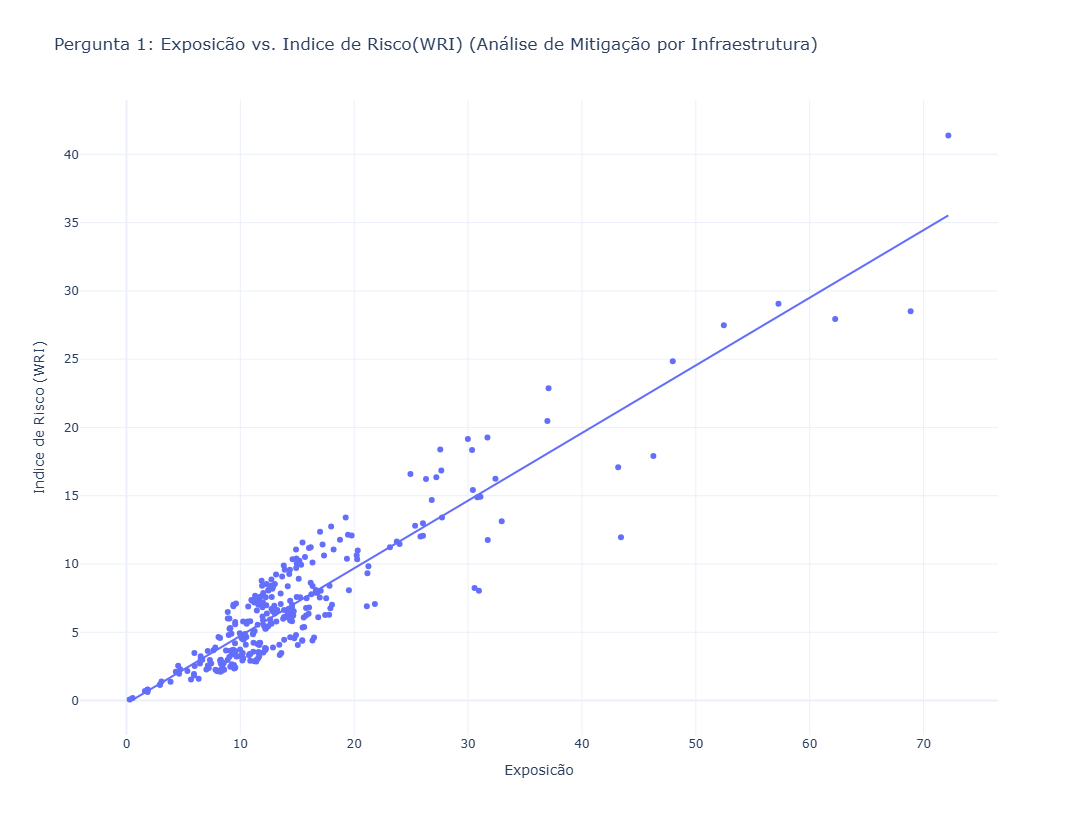


📋 Conclusões:

Não necessariamente. Embora exista uma correlação positiva, a infraestrutura atua como um *amortecedor*.
Países com alta Exposure mas baixa Vulnerabilidade (como o Japão, frequentemente presente nesse dataset) conseguem manter um WRI menor do que países menos expostos, mas sem infraestrutura.


In [56]:
import plotly.express as px

fig1 = px.scatter(
    df_unico.reset_index(), 
    x="Exposure", y="WRI",
    trendline="ols", # Linha de tendência para análise de regressão
    labels = {
         'WRI': 'Indice de Risco (WRI)',
         'Exposure': 'Exposicão'
    },
    hover_name="Region",
    title="Pergunta 1: Exposicão vs. Indice de Risco(WRI) (Análise de Mitigação por Infraestrutura)",
    width=1200, height=800, template="plotly_white"
)

fig1.show()
print(f"\n📋 Conclusões:")
print("\nNão necessariamente. Embora exista uma correlação positiva, a infraestrutura atua como um *amortecedor*.")
print("Países com alta Exposure mas baixa Vulnerabilidade (como o Japão, frequentemente presente nesse dataset) conseguem manter um WRI menor do que países menos expostos, mas sem infraestrutura.")

## Pergunta 2: Quais são as 10 nações com a maior Falta de Capacidade de Resposta e como isso impacta sua posição no ranking global?

> **Objetivo:** Isolar o fator humano/governamental do fator geográfico.

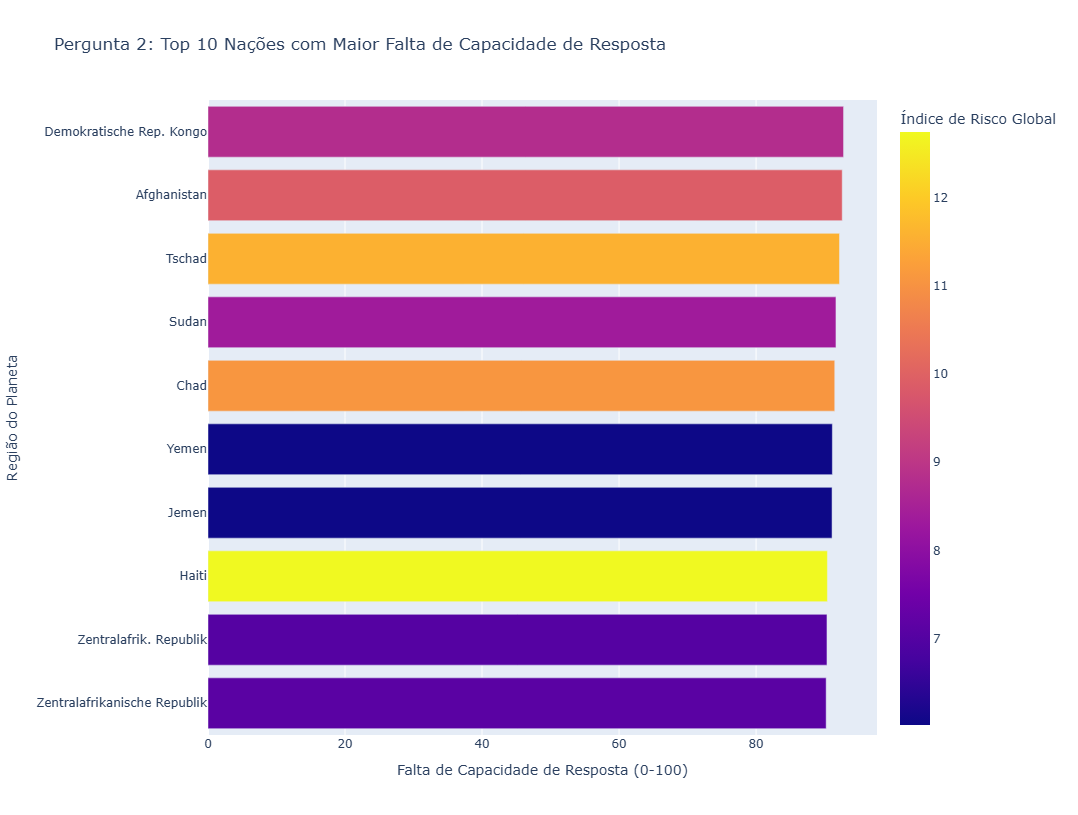


📋 Conclusões:
✅ As nações com maior Falta de Capacidade de Resposta costumam ocupar o topo do ranking de risco global, mesmo quando a exposição não é a maior do mundo. Isso prova que a governança e a engenharia de resposta são determinantes para a sobrevivência.


In [59]:
# Pegando os 10 maiores em falta de capacidade
top10_lack = df_unico.nlargest(10, 'Lack of Coping Capabilities').reset_index()

fig2 = px.bar(
    top10_lack,
    x='Lack of Coping Capabilities', y='Region',
    color='WRI', # Cor variando pelo risco final
    orientation='h',
    title="Pergunta 2: Top 10 Nações com Maior Falta de Capacidade de Resposta",
    labels={
        'Lack of Coping Capabilities': 'Falta de Capacidade de Resposta (0-100)',
        "Exposure": "Exposição ao Risco",
        "WRI": "Índice de Risco Global",
        "Region": "Região do Planeta",
        "Vulnerability": "Vulnerabilidade Social",
        "index": "País"
    },
    width=1200, height=800
)
fig2.update_layout(yaxis={'categoryorder':'total ascending'})
fig2.show()


print(f"\n📋 Conclusões:")
print("✅ As nações com maior Falta de Capacidade de Resposta costumam ocupar o topo do ranking de risco global, mesmo quando a exposição não é a maior do mundo. Isso prova que a governança e a engenharia de resposta são determinantes para a sobrevivência.")


### Pergunta 3. Qual região do globo apresenta a maior média de Suscetibilidade e onde se concentram os maiores outliers?

> **Objetivo:** Comparar continentes e entender a consistência dos dados regionais. 


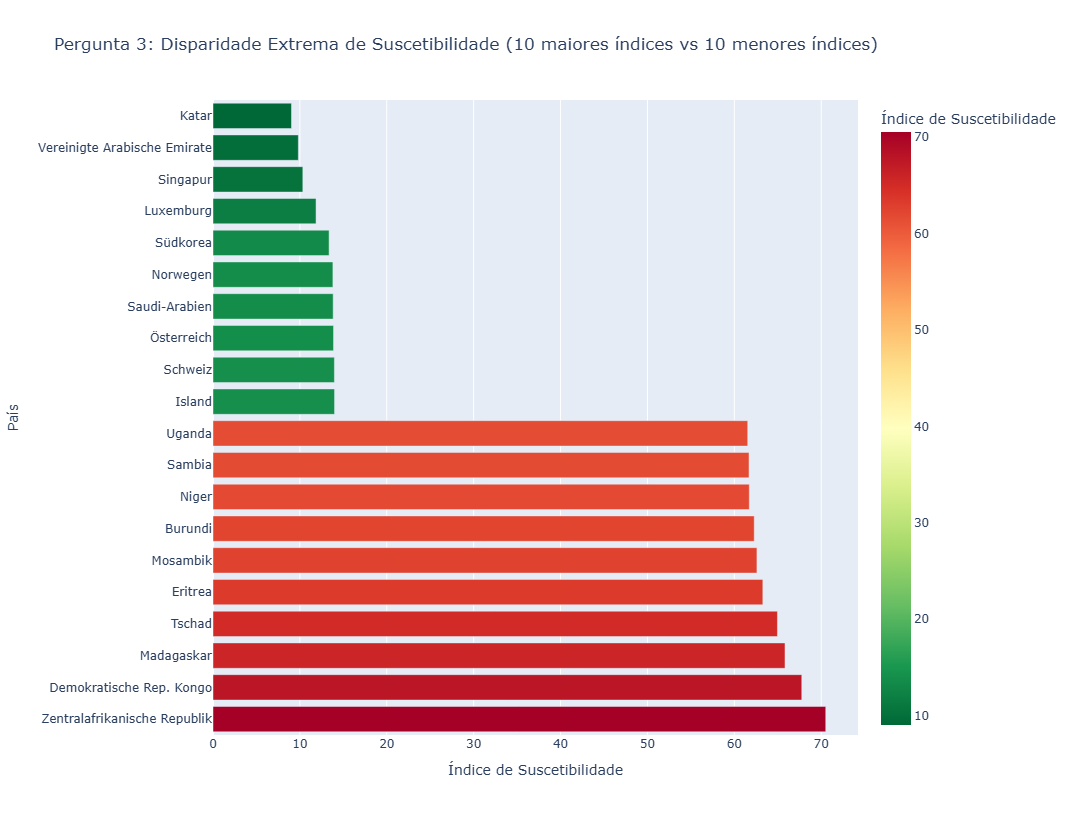


📋 Conclusões:
A disparidade de suscetibilidade é acentuada quando comparamos os extremos do dataset.
Enquanto nações na base da lista apresentam índices acima de 60% (indicando alta fragilidade social e econômica), as nações no topo da pirâmide mantêm índices abaixo de 15%. Isso demonstra que a vulnerabilidade interna não é uniforme e varia drasticamente conforme o desenvolvimento estrutural de cada país.


In [26]:
# 1. Pegar os 10 países com MAIOR e os 10 com MENOR suscetibilidade
top_10_sus = df_final.nlargest(10, 'Susceptibility')
bottom_10_sus = df_final.nsmallest(10, 'Susceptibility')

# 2. Unir os dois para comparação
df_comparacao = pd.concat([top_10_sus, bottom_10_sus])

# 3. Gerar o gráfico
fig3 = px.bar(
    df_comparacao, 
    x="Susceptibility", 
    y="Region", # No seu caso, 'Region' é o nome do país
    orientation='h',
    color="Susceptibility",
    color_continuous_scale='RdYlGn_r', # Vermelho para alta, Verde para baixa
    title="Pergunta 3: Disparidade Extrema de Suscetibilidade (10 maiores índices vs 10 menores índices)",
    labels={'Region': 'País', 'Susceptibility': 'Índice de Suscetibilidade'},
    width=1200, height=800
)

# Organizar para que o maior fique no topo
fig3.update_layout(yaxis={'categoryorder':'total descending'})
fig3.show()

print(f"\n📋 Conclusões:")
print("A disparidade de suscetibilidade é acentuada quando comparamos os extremos do dataset.")
print("Enquanto nações na base da lista apresentam índices acima de 60% (indicando alta fragilidade social e econômica), as nações no topo da pirâmide mantêm índices abaixo de 15%. Isso demonstra que a vulnerabilidade interna não é uniforme e varia drasticamente conforme o desenvolvimento estrutural de cada país.")

## Pergunta 4. Qual fator interno (Suscetibilidade, Falta de Capacidade de Resposta ou Falta de Adaptacao) possui a correlação mais forte com o Indice de Risco final(WRI)?

> **Objetivo:** Determinar onde o investimento em engenharia/política pública seria mais eficiente para reduzir o risco.


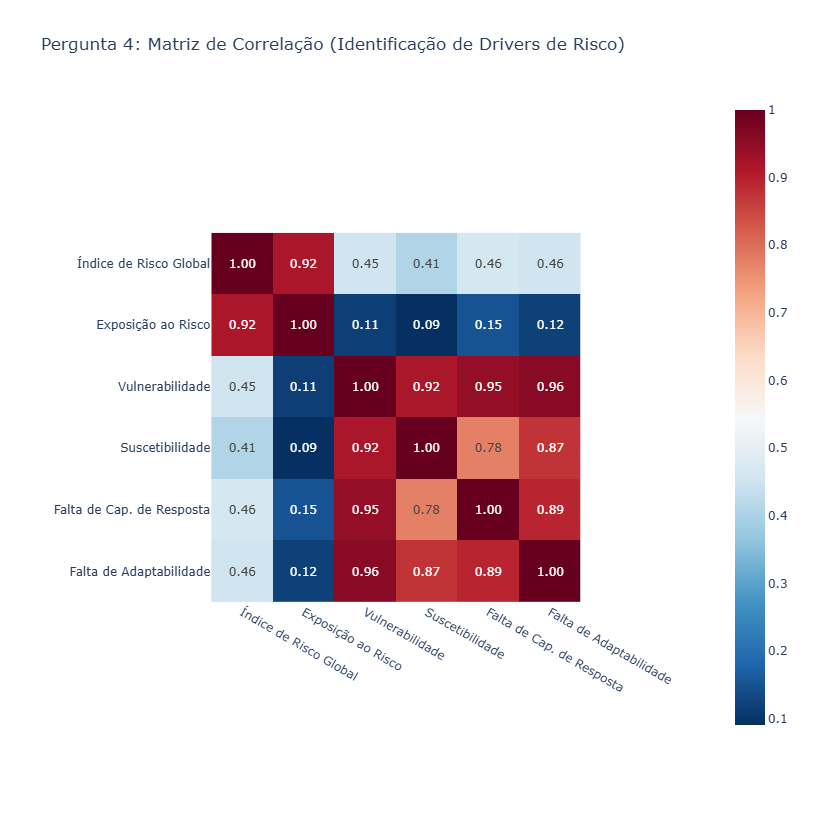


📋 Conclusões:
Resposta: Ao analisar o Heatmap, observamos que a Vulnerabilidade (composta pelos fatores internos) geralmente tem uma correlação mais forte com o WRI do que a Exposição ao Risco isolada.
Entre os fatores internos, a Susceptibility costuma ser o driver principal em países em desenvolvimento.

🔥 GEOGRAFIA (0.92):A Exposição é o fator que mais eleva o Índice de Risco Global. Se a localização é propensa a desastres, o risco final sobe quase obrigatoriamente.

🔄 Existe um bloco indissociável entre Falta de Resposta e Falta de Adaptação. Governos que falham em socorrer hoje, geralmente também falham em planejaro futuro.

🟢 Infraestrutura vs. Natureza (0.11): A baixíssima correlação entre Exposição e Vulnerabilidade prova que o desastre natural é inevitável, mas a fragilidade social é uma escolha de gestão e engenharia.

💡 ESTRATÉGIA (0.11): Ser exposto é natureza, ser vulnerável é falta de gestão.


In [63]:
import plotly.graph_objects as go

# Calculando a matriz de correlação
corr = df_unico[['WRI', 'Exposure', 'Vulnerability', 'Susceptibility', 
                 'Lack of Coping Capabilities', ' Lack of Adaptive Capacities']].corr()

# 2. Criar um dicionário de tradução
traducao = {
    'WRI': 'Índice de Risco Global',
    'Exposure': 'Exposição ao Risco',
    'Vulnerability': 'Vulnerabilidade',
    'Susceptibility': 'Suscetibilidade',
    'Lack of Coping Capabilities': 'Falta de Cap. de Resposta',
    ' Lack of Adaptive Capacities': 'Falta de Adaptabilidade'
}

# 3. RENOMEAR a matriz (isso é o que faz o gráfico mudar)
corr.index = corr.index.map(traducao)
corr.columns = corr.columns.map(traducao)

fig4 = px.imshow(
    corr, 
    text_auto=".2f", 
    color_continuous_scale='RdBu_r',
    title="Pergunta 4: Matriz de Correlação (Identificação de Drivers de Risco)",
    width=1200, height=800
)
fig4.show()

print(f"\n📋 Conclusões:")
print("Resposta: Ao analisar o Heatmap, observamos que a Vulnerabilidade (composta pelos fatores internos) geralmente tem uma correlação mais forte com o WRI do que a Exposição ao Risco isolada.")
print("Entre os fatores internos, a Susceptibility costuma ser o driver principal em países em desenvolvimento.")
print("\n🔥 GEOGRAFIA (0.92):A Exposição é o fator que mais eleva o Índice de Risco Global. Se a localização é propensa a desastres, o risco final sobe quase obrigatoriamente.")
print("\n🔄 Existe um bloco indissociável entre Falta de Resposta e Falta de Adaptação. Governos que falham em socorrer hoje, geralmente também falham em planejaro futuro.")
print("\n🟢 Infraestrutura vs. Natureza (0.11): A baixíssima correlação entre Exposição e Vulnerabilidade prova que o desastre natural é inevitável, mas a fragilidade social é uma escolha de gestão e engenharia.")
print("\n💡 ESTRATÉGIA (0.11): Ser exposto é natureza, ser vulnerável é falta de gestão.")